# Circuit Insights: WeightLens and CircuitLens

What does feature **layer 0 / index 24** respond to? We inspect it from two directions:

- **WeightLens** projects the feature into token space.
- **CircuitLens** traces which attention heads and source tokens drive it in context.

The model and transcoders come from the public [Circuit Tracer](https://github.com/safety-research/circuit-tracer) release for Gemma-2-2B.

## Load the feature

This notebook needs Gemma access on Hugging Face and about 16 GB of accelerator memory. The bundled sample contains 12 published inputs for the chosen feature.

### Workflow and figure exports

The schematic summarizes the artifact dependencies; the executable `Workflow`
definitions appear below. Model configuration is fixed, while per-example results
pass between stages through TensorDict keys.

Every figure is displayed here and exported to `figures/` in the working
directory as an editable SVG and a 300-dpi PNG. The exported files use the same data as the inline figures.

In [1]:
from __future__ import annotations
import json
import os
import random
import re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
import torch
from circuit_tracer import ReplacementModel
from huggingface_hub import snapshot_download
from IPython.display import Markdown, display
from tensordict import NonTensorData, TensorDict
from tensordict.nn import TensorDictModule
from transformers import AutoTokenizer
from tdhook.attribution import CircuitLensArtifact, attention_contributions, cluster_circuit_artifacts
from tdhook.weights import analyze_input_invariant_feature, select_projection_outliers
from tdhook.workflow import Workflow
from tdhook.latent import ActivationCaching

SEED = 127
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)

In [2]:
import sys

tutorial_path = Path("docs/source/notebooks/tutorials")
tutorial_dir = next(
    (root / tutorial_path for root in (Path.cwd(), *Path.cwd().parents) if (root / tutorial_path).is_dir()), Path.cwd()
)
sys.path.insert(0, str(tutorial_dir))
from notebook_figures import STYLE, BLUE, ORANGE, TEAL, GRAY, finish_figure, workflow_figure  # noqa: E402

plt.rcParams.update(STYLE)

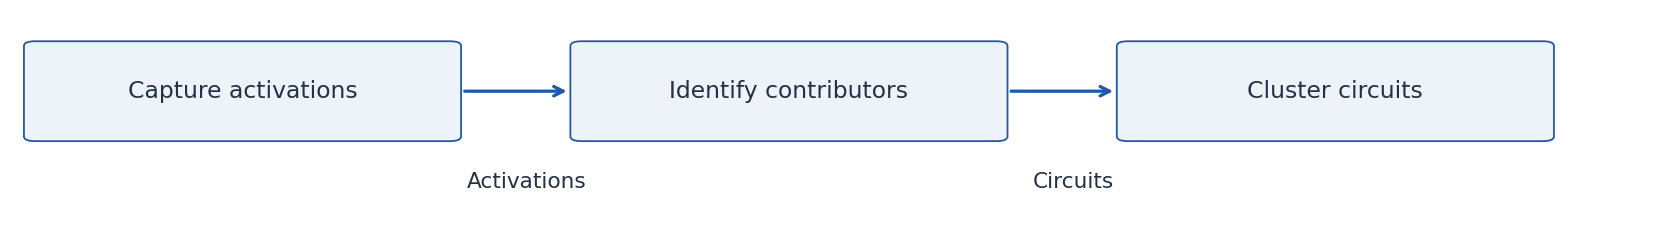

In [3]:
workflow_figure(
    ["Capture activations", "Identify contributors", "Cluster circuits"],
    ["Activations", "Circuits"],
    "weight-circuit-research-reproduction-workflow",
);

In [4]:
if not torch.cuda.is_available():
    raise RuntimeError("This Gemma-2-2B notebook requires CUDA.")
device = torch.device("cuda")
dtype = torch.bfloat16
reference_relative_path = Path("docs/source/notebooks/assets/gemma-2-2b-feature-24-reference.json")
reference_path = next(
    root / reference_relative_path
    for root in (Path.cwd(), *Path.cwd().parents)
    if (root / reference_relative_path).is_file()
)
reference = json.loads(reference_path.read_text())
feature_layer = reference["feature"]["layer"]
feature_index = reference["feature"]["index"]

In [5]:
model_snapshot = snapshot_download(
    reference["provenance"]["model"],
    revision=reference["provenance"]["model_revision"],
    allow_patterns=[
        "config.json",
        "special_tokens_map.json",
        "tokenizer.json",
        "tokenizer.model",
        "tokenizer_config.json",
    ],
)
tokenizer = AutoTokenizer.from_pretrained(model_snapshot)
model = ReplacementModel.from_pretrained(
    reference["provenance"]["model"],
    f"{reference['provenance']['transcoder_set']}@{reference['provenance']['transcoder_revision']}",
    revision=reference["provenance"]["model_revision"],
    device=device,
    dtype=dtype,
    tokenizer=tokenizer,
)
model.eval()
selected_transcoder = model.transcoders[feature_layer]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Fetching 26 files:   0%|          | 0/26 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model google/gemma-2-2b into HookedTransformer


In [6]:
def encoder_for_tdhook(transcoder):
    """Normalize circuit-tracer releases to TDHook's [model, feature] convention."""
    weights = transcoder.W_enc
    if weights.shape[0] == model.cfg.d_model:
        return weights
    if weights.shape[1] == model.cfg.d_model:
        return weights.T
    raise ValueError(f"Unrecognized encoder shape: {tuple(weights.shape)}")

In [7]:
# The selected feature is in layer 0, so WeightLens needs no earlier dictionaries.
# Keeping one layer also avoids materializing every lazily loaded decoder.
feature_encoders = (encoder_for_tdhook(selected_transcoder),)
feature_decoders = (selected_transcoder.W_dec,)
token_labels = tuple(model.tokenizer.decode([index]) for index in range(model.cfg.d_vocab))

## WeightLens: token associations

A `Workflow` projects the feature encoder into the embedding dictionary and its decoder into the output dictionary, then publishes the selected token views as named TensorDict artifacts. Large positive or negative projections reveal the feature's input and output associations.

In [8]:
def project_feature():
    artifact = analyze_input_invariant_feature(
        feature_layer=feature_layer,
        feature_index=feature_index,
        embedding=model.W_E,
        unembedding=model.W_U,
        feature_encoders=feature_encoders,
        feature_decoders=feature_decoders,
        token_outlier_threshold=5.5,
        feature_outlier_threshold=4.0,
        token_pool_size=1000,
        feature_pool_size=100,
        input_token_labels=token_labels,
        output_token_labels=token_labels,
    )
    return NonTensorData(artifact)

In [9]:
def select_token_views(artifact):
    inputs = (*artifact.embedding_negative, *artifact.embedding_positive)
    return NonTensorData(inputs), NonTensorData(tuple(artifact.output_positive))

Compose feature projection and token selection, then inspect the resulting artifacts.

In [10]:
weight_lens_workflow = Workflow(
    TensorDictModule(project_feature, in_keys=[], out_keys=[("artifacts", "weight_lens")]),
    TensorDictModule(
        select_token_views,
        in_keys=[("artifacts", "weight_lens")],
        out_keys=[("views", "input_tokens"), ("views", "output_tokens")],
    ),
)

In [11]:
weight_result = weight_lens_workflow(model, TensorDict({}, batch_size=[]))
weight_artifact = weight_result[("artifacts", "weight_lens")]
input_items = list(weight_result[("views", "input_tokens")])
output_items = list(weight_result[("views", "output_tokens")])

In [12]:
def plot_token_projections(input_items, output_items):
    with plt.rc_context(STYLE):
        figure, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
        for axis, items, title in zip(
            axes, (input_items, output_items), ("Input-token associations", "Output-token associations")
        ):
            scores = [item.score for item in items]
            bars = axis.barh(
                [repr(item.label) for item in items],
                scores,
                color=[ORANGE if value < 0 else BLUE for value in scores],
                height=0.65,
            )
            axis.bar_label(bars, fmt="%.1f", padding=5, fontsize=12)
            axis.axvline(0, color=GRAY, linewidth=0.8)
            axis.set(title=title, xlabel="Projection score")
            axis.invert_yaxis()
            axis.margins(x=0.25)
        figure.suptitle("WeightLens · Gemma-2-2B, layer 0 / feature 24", fontsize=20)
        finish_figure(figure, "circuit-token-associations")

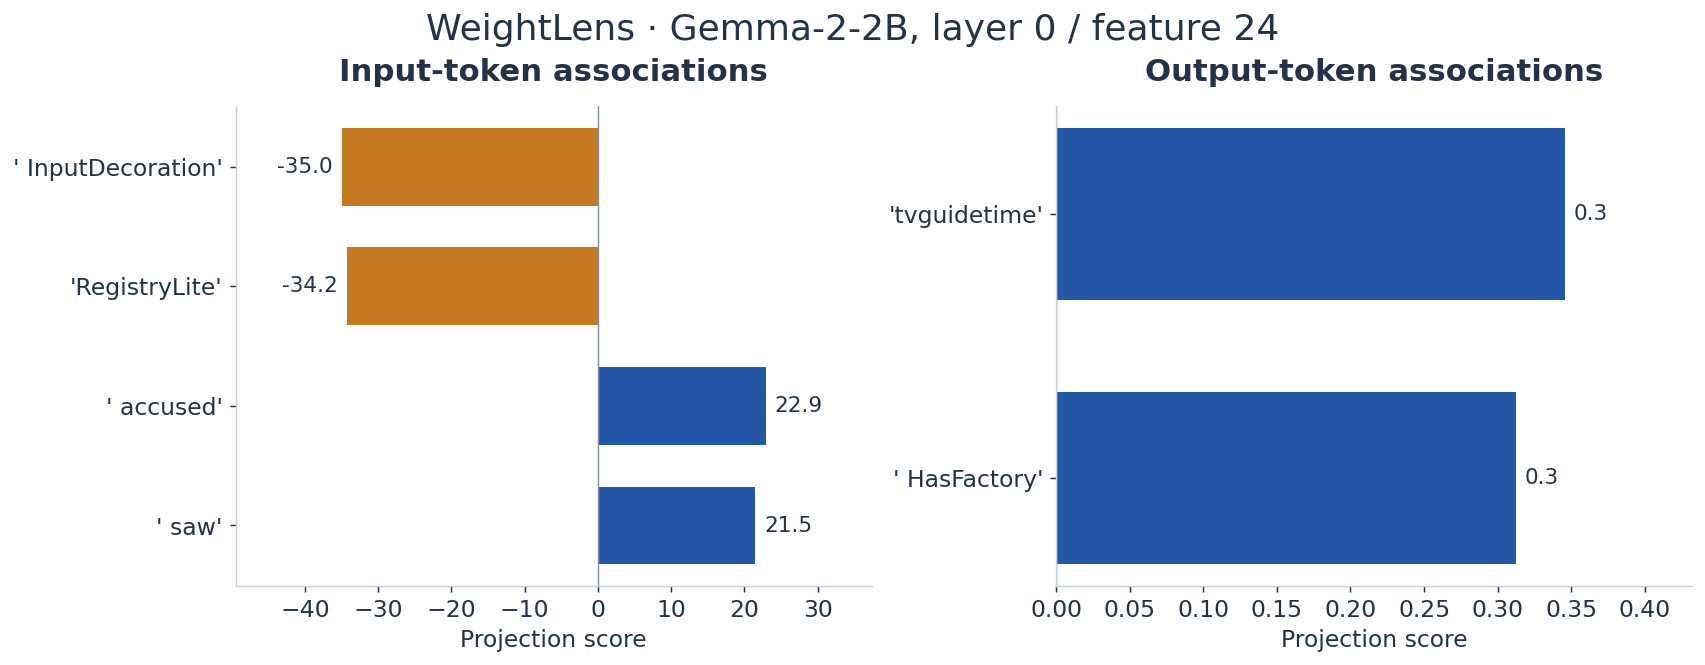

In [13]:
plot_token_projections(input_items, output_items)

## CircuitLens: contextual inputs

For each input, we decompose the layer-0 attention output and select the strongest head-to-token contributions. The scatter plot compares the observed feature activation with the published run; the heatmap shows which heads contribute in each example.

Each input runs through `ActivationCaching` → contributor analysis. The analysis consumes the captured tensors by key; circuit artifacts are produced inside the workflow. A second workflow compares activations and clusters the batch of produced circuits.

In [14]:
pattern_name = "module.blocks.0.attn.hook_pattern"
value_name = "module.blocks.0.attn.hook_v"
feature_input_name = f"module.blocks.0.{model.feature_input_hook}"
cache_key = ("activations", "circuit")
names = (pattern_name, value_name, feature_input_name)
encoder = feature_encoders[feature_layer][:, feature_index].detach().float().cpu()
output_weight = model.blocks[0].attn.W_O.detach().float().cpu()
circuit_model = TensorDictModule(model, in_keys={"input": "input", "stop_at_layer": "stop_at_layer"}, out_keys=["_"])

In [15]:
def analyze_sample(pattern, values, feature_input, sample):
    """Select attention contributors and measure the target feature activation."""
    pattern = pattern[0].detach().float().cpu()
    values = values[0].detach().float().cpu()
    if values.shape[1] != pattern.shape[0]:
        values = values.repeat_interleave(pattern.shape[0] // values.shape[1], dim=1)

    position = sample["target_position"]
    output_gradient = torch.zeros(pattern.shape[1], model.cfg.d_model)
    output_gradient[position] = encoder
    all_attention = attention_contributions(
        pattern,
        values,
        output_weight,
        output_gradient,
        layer=0,
        target_position=position,
    )
    selected_positions = select_projection_outliers(
        torch.tensor([item.score for item in all_attention]), threshold=5.0, largest=True
    )
    selected = tuple(all_attention[item.index] for item in selected_positions)
    feature_input = feature_input[0, position].detach()
    activation = float(selected_transcoder.encode(feature_input)[feature_index].float().cpu())
    artifact = CircuitLensArtifact(
        target_layer=feature_layer,
        target_feature_index=feature_index,
        target_position=(position,),
        target_activation=activation,
        upstream_features=(),
        attention=selected,
        output_logits=(),
    )
    return NonTensorData(artifact), torch.tensor(activation)

In [16]:
circuit_workflow = Workflow(
    ActivationCaching("|".join(re.escape(name) for name in names), cache_key=cache_key),
    TensorDictModule(
        analyze_sample,
        in_keys=[(*cache_key, pattern_name), (*cache_key, value_name), (*cache_key, feature_input_name), "sample"],
        out_keys=[("artifacts", "circuit"), ("activations", "observed")],
    ),
)

In [17]:
circuit_results = []
for sample in reference["samples"]:
    data = TensorDict(
        {
            "input": torch.tensor(sample["input_ids"], device=device).unsqueeze(0),
            "stop_at_layer": NonTensorData(1),
            "sample": NonTensorData(sample),
        },
        batch_size=[],
    )
    with torch.no_grad():
        circuit_results.append(circuit_workflow(circuit_model, data))

In [18]:
def cluster_circuits(artifacts):
    return NonTensorData(
        cluster_circuit_artifacts(
            artifacts,
            min_frequency=0.05,
            min_abs_score=0.0,
            eps=0.8,
            min_samples=2,
        )
    )

In [19]:
circuit_summary_workflow = Workflow(
    TensorDictModule(
        lambda observed, published: (observed - published).abs(),
        in_keys=[("activations", "observed"), ("activations", "published")],
        out_keys=[("metrics", "activation_error")],
    ),
    TensorDictModule(cluster_circuits, in_keys=[("artifacts", "circuits")], out_keys=[("artifacts", "clusters")]),
)

In [20]:
circuit_artifacts = [result["artifacts", "circuit"] for result in circuit_results]
observed_activations = [float(result["activations", "observed"]) for result in circuit_results]
published_activations = [sample["target_activation"] for sample in reference["samples"]]
circuit_result = circuit_summary_workflow(
    model,
    TensorDict(
        {
            ("artifacts", "circuits"): NonTensorData(tuple(circuit_artifacts)),
            ("activations", "observed"): torch.tensor(observed_activations),
            ("activations", "published"): torch.tensor(published_activations),
        },
        batch_size=[],
    ),
)
clusters = circuit_result["artifacts", "clusters"]

In [21]:
def contributor_views(artifacts, samples):
    grid = np.zeros((8, len(samples)))
    rows = []
    for sample_index, (artifact, sample) in enumerate(zip(artifacts, samples, strict=True)):
        for item in artifact.attention:
            grid[item.head_index, sample_index] += abs(item.score)
        contributors = ", ".join(
            f"H{item.head_index} ← {model.tokenizer.decode([sample['input_ids'][item.source_token]])!r}"
            for item in artifact.attention
        )
        rows.append({"Text": model.tokenizer.decode(sample["input_ids"]), "Contributors": contributors or "—"})
    return grid, rows

In [22]:
contributor_grid, example_rows = contributor_views(circuit_artifacts, reference["samples"])

In [23]:
def plot_circuit_contributions(published_activations, observed_activations, contributor_grid):
    with plt.rc_context(STYLE):
        figure, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
        axes[0].scatter(published_activations, observed_activations, s=65, color=BLUE, zorder=3)
        limits = [min(published_activations + observed_activations), max(published_activations + observed_activations)]
        axes[0].plot(limits, limits, linestyle="--", color=GRAY, label="Exact agreement")
        axes[0].set(title="Feature activation", xlabel="Published activation", ylabel="TDHook activation")
        axes[0].legend(frameon=False, fontsize=11)
        image = axes[1].imshow(contributor_grid, aspect="auto", cmap="Blues", origin="lower", vmin=0)
        axes[1].set(title="Selected attention contributors", xlabel="Published example", ylabel="Attention head")
        axes[1].set_xticks(range(len(observed_activations)), range(1, len(observed_activations) + 1))
        axes[1].set_yticks(range(contributor_grid.shape[0]))
        figure.colorbar(image, ax=axes[1], label="Sum of absolute selected scores", shrink=0.85)
        figure.suptitle("CircuitLens · 12 published contexts", fontsize=20)
        finish_figure(figure, "circuit-activation-and-contributors")

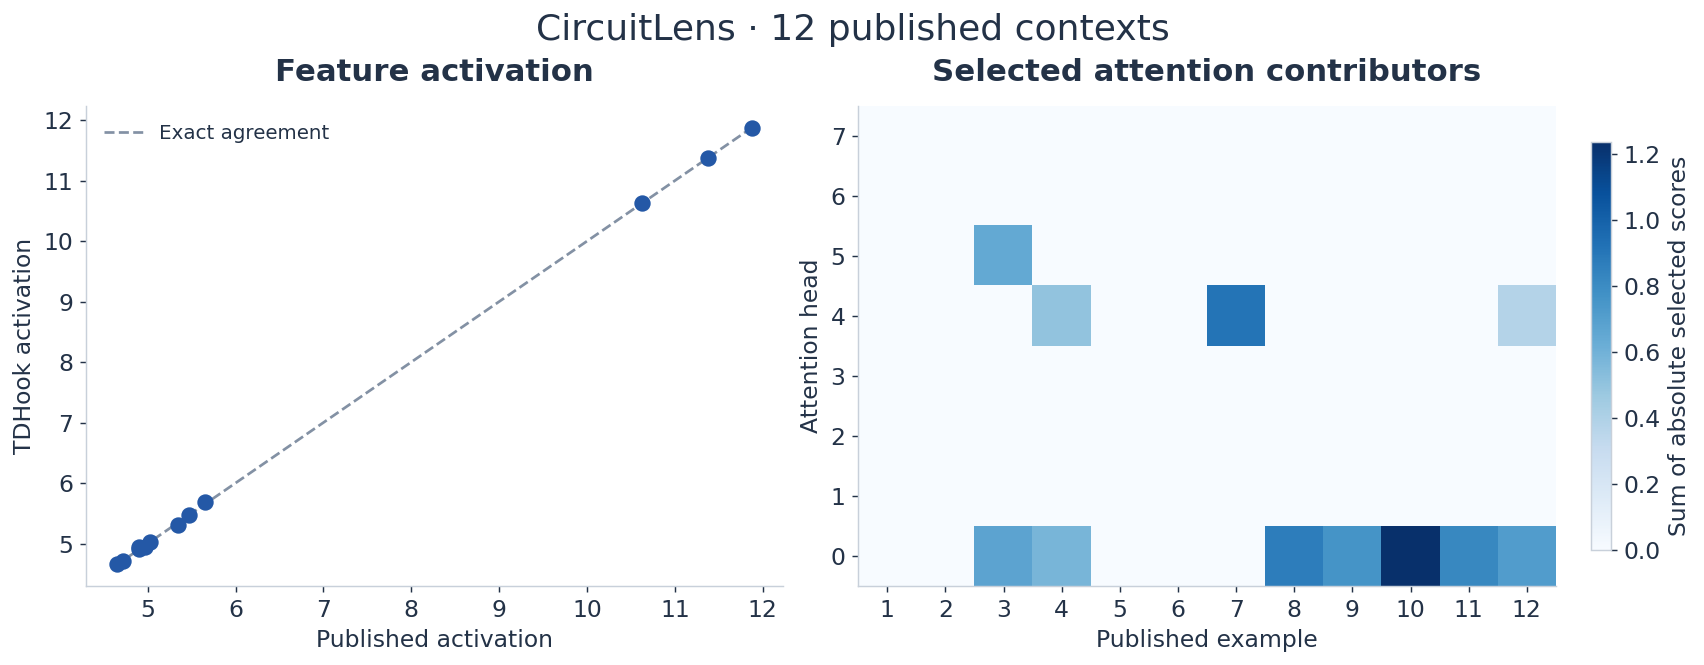

Text,Contributors
But we saw,—
We saw,—
"Since $q(X)=\dim (X)$, we saw","H0 ← ' we', H5 ← ' we'"
"This provides an explicit example for the more general result of [@Litim:2001fd], which states that the optimisation entails a minimum sensitivity condition, while the converse, in general, is not true","H0 ← ' not', H4 ← ' not'"
It may be true,—
One can then pass,—
Actually this is very hard,H4 ← ' very'
For the application purpose it is always desired,H0 ← ' always'
"In fact, the converse is also true",H0 ← ' also'
At first sight one might suspect,H0 ← ' might'


In [24]:
plot_circuit_contributions(published_activations, observed_activations, contributor_grid)
display(pd.DataFrame(example_rows).style.hide(axis="index"))

### One contextual circuit

The example below is selected deterministically by the largest number of selected
contributors (first example on ties). Arrows show the selected head/token scores,
not an exhaustive circuit or a new causal intervention. Negative scores are orange.

In [25]:
def plot_context_circuit(artifact, sample, example_index):
    import textwrap

    selected = sorted(artifact.attention, key=lambda item: abs(item.score), reverse=True)[:8]
    with plt.rc_context(STYLE):
        figure, axis = plt.subplots(figsize=(13, 6))
        axis.set(xlim=(0, 1), ylim=(-0.2, 1.2))
        axis.axis("off")
        axis.text(0.03, 1.08, f"Example {example_index + 1} · selected token-to-feature paths", fontsize=19)
        axis.text(0.03, 0.97, textwrap.fill(model.tokenizer.decode(sample["input_ids"]), 105), fontsize=12, va="top")
        axis.text(
            0.80,
            0.40,
            f"Layer 0 / feature 24\nactivation = {artifact.target_activation:.2f}",
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.8", fc="#EEF3F9", ec=BLUE),
        )
        maximum = max((abs(item.score) for item in selected), default=1)
        for item, y in zip(selected, np.linspace(0.72, 0.05, len(selected))):
            token = model.tokenizer.decode([sample["input_ids"][item.source_token]])
            axis.text(0.04, y, f"{token!r} · token {item.source_token} · H{item.head_index}", va="center", fontsize=12)
            axis.annotate(
                "",
                (0.67, 0.40),
                (0.42, y),
                arrowprops=dict(
                    arrowstyle="->",
                    color=BLUE if item.score >= 0 else ORANGE,
                    lw=1 + 3 * abs(item.score) / maximum,
                    alpha=0.75,
                ),
            )
            axis.text(0.38, y, f"{item.score:+.2f}", ha="right", va="center", fontsize=11)
        axis.text(
            0.03,
            -0.13,
            f"Showing {len(selected)} of {len(artifact.attention)} selected contributors; arrow width = absolute score.",
            fontsize=11,
        )
        figure.tight_layout()
        finish_figure(figure, "circuit-contextual-paths")

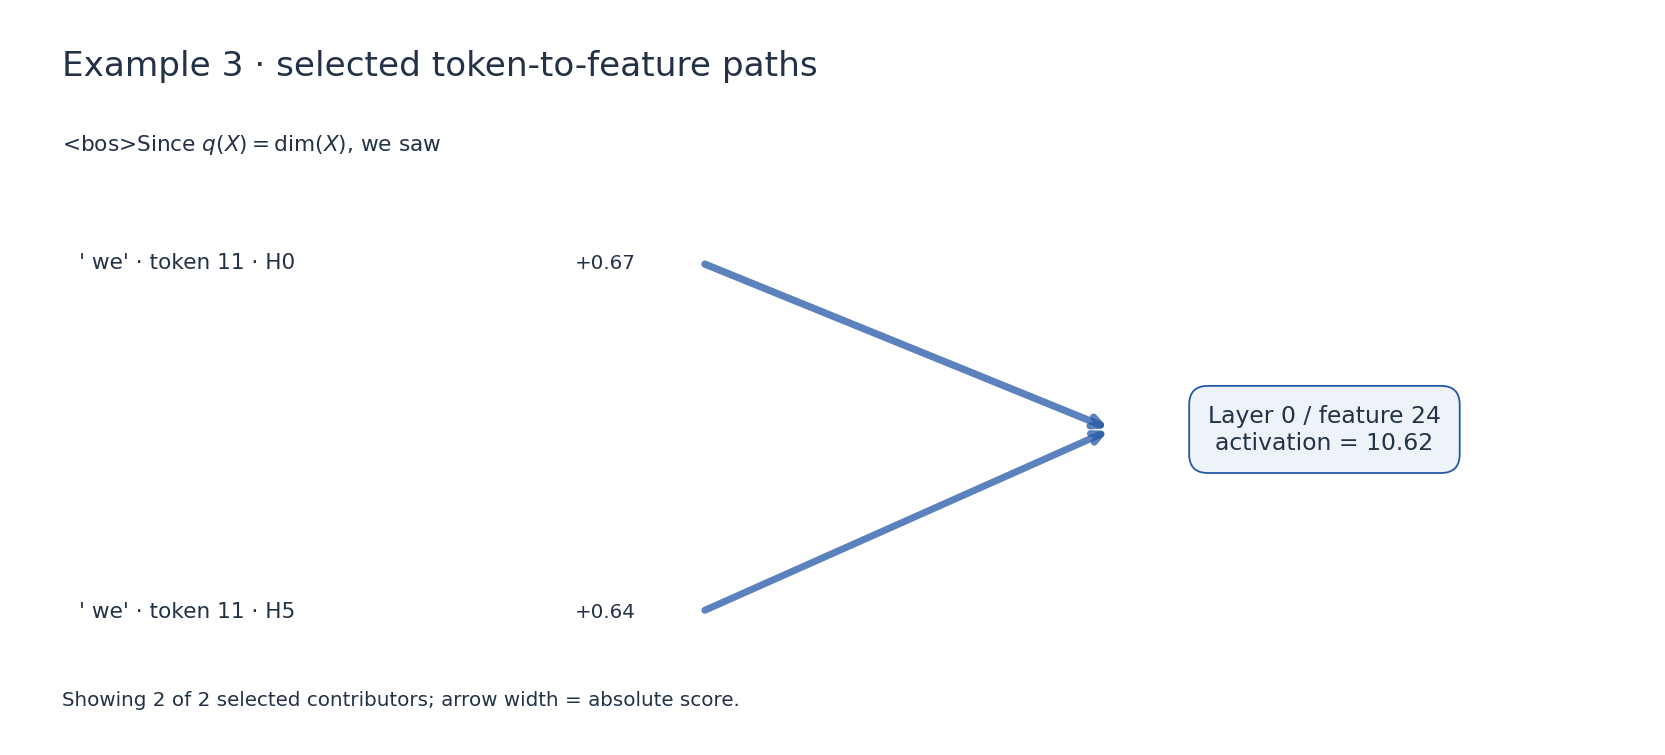

In [26]:
example_index = max(range(len(circuit_artifacts)), key=lambda index: len(circuit_artifacts[index].attention))
plot_context_circuit(circuit_artifacts[example_index], reference["samples"][example_index], example_index)

## Cluster the recurring circuits

Finally, a summary `Workflow` consumes the circuits produced by the capture-and-analysis workflow, measures activation agreement, and clusters the relative-token signatures. Even in this small sample, the examples with non-empty attention circuits form a clear recurring group.

In [27]:
def plot_circuit_clusters(clusters, artifacts):
    empty_labels = [
        label
        for label in sorted(set(clusters.labels))
        if label >= 0
        and all(not artifact.attention for assigned, artifact in zip(clusters.labels, artifacts) if assigned == label)
    ]
    with plt.rc_context(STYLE):
        figure, axis = plt.subplots(figsize=(13, 3), constrained_layout=True)
        palette = [BLUE, TEAL, ORANGE, "#79599B"]
        colors = [GRAY if label < 0 else palette[label % len(palette)] for label in clusters.labels]
        axis.scatter(
            range(1, len(clusters.labels) + 1),
            np.zeros(len(clusters.labels)),
            c=colors,
            s=700,
            edgecolor="white",
            linewidth=2,
        )
        for index, label in enumerate(clusters.labels, start=1):
            axis.text(
                index,
                0,
                "–" if label < 0 else str(label),
                ha="center",
                va="center",
                color="white",
                fontweight="bold",
                fontsize=14,
            )
        axis.set(title="Recurring circuit signatures", xlabel="Published example", ylim=(-0.45, 0.45))
        axis.set_xticks(range(1, len(clusters.labels) + 1))
        axis.set_yticks([])
        axis.spines[:].set_visible(False)
        note = (
            f"Empty contributor sets: cluster {', '.join(map(str, empty_labels))}"
            if empty_labels
            else "Relative-token signatures"
        )
        figure.suptitle(note + " · gray denotes unclustered examples", fontsize=13)
        finish_figure(figure, "circuit-signature-clusters")

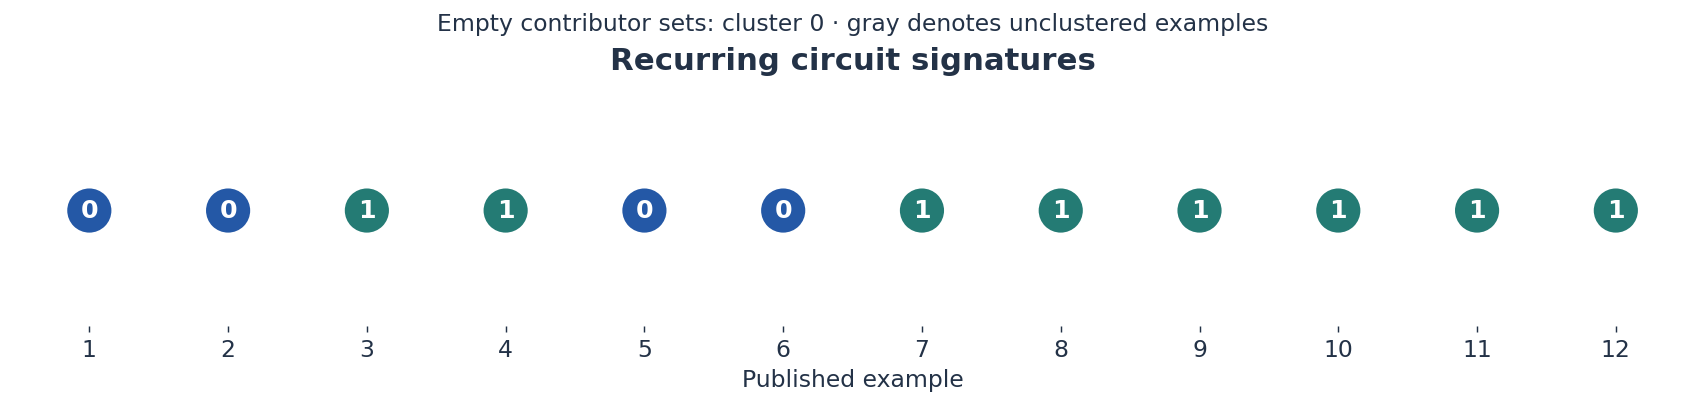

TDHook selected the same contributors as the published sample in **12 of 12 examples**.

In [28]:
plot_circuit_clusters(clusters, circuit_artifacts)
display(
    Markdown(
        f"TDHook selected the same contributors as the published sample in "
        f"**{sum(set((item.head_index, item.source_token) for item in artifact.attention) == set((entry['head'], entry['source_token']) for entry in sample['attention']) for artifact, sample in zip(circuit_artifacts, reference['samples']))} of 12 examples**."
    )
)

## Takeaway

WeightLens associates this feature with input tokens such as `accused` and `saw`. CircuitLens then shows how a small set of layer-0 attention heads route contextual evidence into the feature. The two views agree with the published feature sample while exposing different parts of the mechanism.

## Evaluation scope

Weight projections and contextual attention contributors are complementary views,
not a claim that weight-only associations cause the displayed paths. The contextual
diagram shows selected contributors, not an exhaustive causal circuit. A cluster
of empty contributor sets is not evidence for a distinct causal mechanism; the
cluster figure identifies these groups explicitly. Agreement is evaluated on
the 12 published feature contexts, not a full-model benchmark.
